# HOMEWORK 14 (lesson 15)

In this assignment, the Fashion MNIST dataset is used. The provided classifier exhibits significant overfitting, so the main objective is to apply regularization techniques to reduce it.

In [74]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten, Input, MaxPooling2D, BatchNormalization
from tensorflow.keras import Model
from tensorflow.keras.optimizers import Adam
from time import time
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
import optuna

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

### Dataset

The MNIST fashgion dataset [link](https://github.com/zalandoresearch/fashion-mnist) was build by Zalando Reasearch tem consists of monochrome images of different type of clothing, namely:
* 0	T-shirt/top
* 1	Trouser
* 2	Pullover
* 3	Dress
* 4	Coat
* 5	Sandal
* 6	Shirt
* 7	Sneaker
* 8	Bag
* 9	Ankle boot

It is also one of the Keras built-in datasets. Let's load the images and quickly inspect it.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Dataset params
num_classes = 10
size = x_train.shape[1]

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

Train set:    60000 samples
Test set:     10000 samples
Sample dims:  (60000, 28, 28)


Let's visualise some random samples.

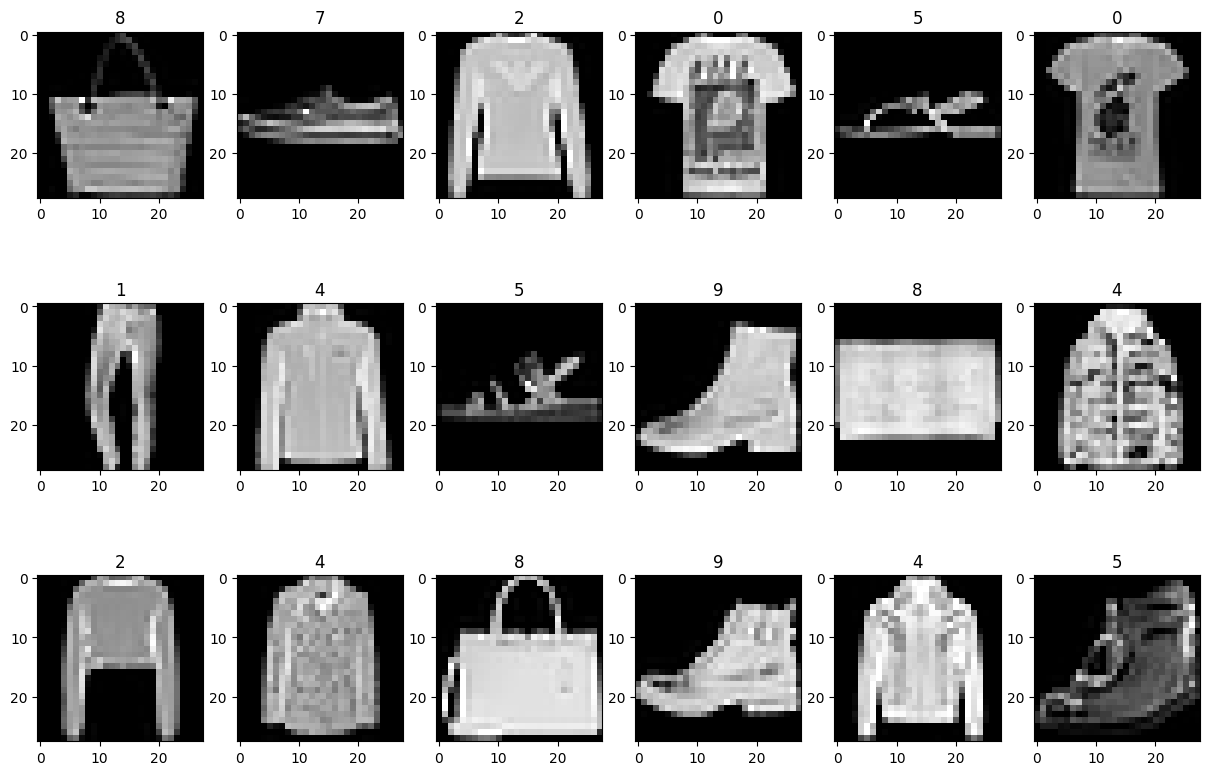

In [3]:
cnt = 1
for r in range(3):
    for c in range(6):
        idx = np.random.randint(len(x_train))
        plt.subplot(3,6,cnt)
        plt.imshow(x_train[idx, ...], cmap='gray')
        plt.title(y_train[idx])
        cnt = cnt + 1

/tmp/ipykernel_3459240/2100990544.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_names, y=counts, palette="viridis")


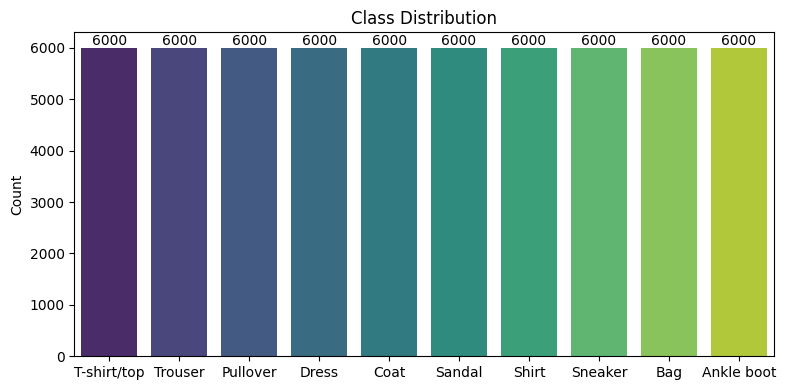

In [47]:
class_names = [
        "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
        "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
    ]

def plot_class_distribution(y):
    unique, counts = np.unique(y, return_counts=True)

    plt.figure(figsize=(8,4))
    ax = sns.barplot(x=class_names, y=counts, palette="viridis")

    for i, v in enumerate(counts):
        ax.text(i, v + 50, str(v), ha='center')

    plt.xticks(rotation=0)
    plt.title("Class Distribution")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

plot_class_distribution(y_train)

In [43]:
shapes = np.array([img.shape for img in x_train])
unique_shapes = np.unique(shapes, axis=0)

print("Unique image shapes:", unique_shapes)

Unique image shapes: [[28 28]]


The dataset is fully balanced: each class contains exactly 6000 samples, so there is no class imbalance and no need for reweighting or resampling.

All images have the same shape (28×28), which confirms that no resizing or additional preprocessing for dimensional consistency is required.

The data quality is good: images are clean, centered, and the objects are clearly distinguishable. However, the low resolution and grayscale format limit the amount of information available, which can make the classification task harder and may contribute to overfitting.

Overall, the dataset is well-prepared and suitable for training, with the main limitation being its simplicity rather than any structural issues.

# Model 1: Baseline

### Building the Classifier

A simple baseline CNN with one convolutional layer and a fully connected classifier for 10-class classification.

In [4]:
# Data normalization
x_train = x_train/255
x_test = x_test/255

In [5]:
inputs = Input(shape=(28, 28, 1))
net = Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same')(inputs)
net = Flatten()(net)
net = Dense(128)(net)
outputs = Dense(10, activation="softmax")(net)

model_baseline = Model(inputs, outputs)
model_baseline.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,213,002 (12.26 MB)

 Trainable params: 3,213,002 (12.26 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
epochs = 50
batch_size = 64

model_baseline.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history_baseline = model_baseline.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test))

Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.8598 - loss: 0.4069 - val_accuracy: 0.8799 - val_loss: 0.3315
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.9044 - loss: 0.2674 - val_accuracy: 0.8875 - val_loss: 0.3106
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.9187 - loss: 0.2259 - val_accuracy: 0.8924 - val_loss: 0.3049
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.9300 - loss: 0.1963 - val_accuracy: 0.8959 - val_loss: 0.3115
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.9390 - loss: 0.1718 - val_accuracy: 0.8971 - val_loss: 0.3292
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.9460 - loss: 0.1529 - val_accuracy: 0.8918 - val_loss: 0.3505
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.9525 - loss: 0.1341 - val_accuracy: 0.8940 - val_loss: 0.3684
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.9580 - loss: 0.1208 - 

In [9]:
def plot_history(history):
    h = history.history
    epochs = range(len(h['loss']))

    plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
    plt.legend(['Train', 'Validation'])
    plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                               epochs, h['val_accuracy'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])

    train_acc = h['accuracy'][-1]
    val_acc = h['val_accuracy'][-1]
        
    print('Train Acc     ', train_acc)
    print('Validation Acc', val_acc)

    return train_acc, val_acc

Train Acc      0.9939666390419006
Validation Acc 0.8798999786376953


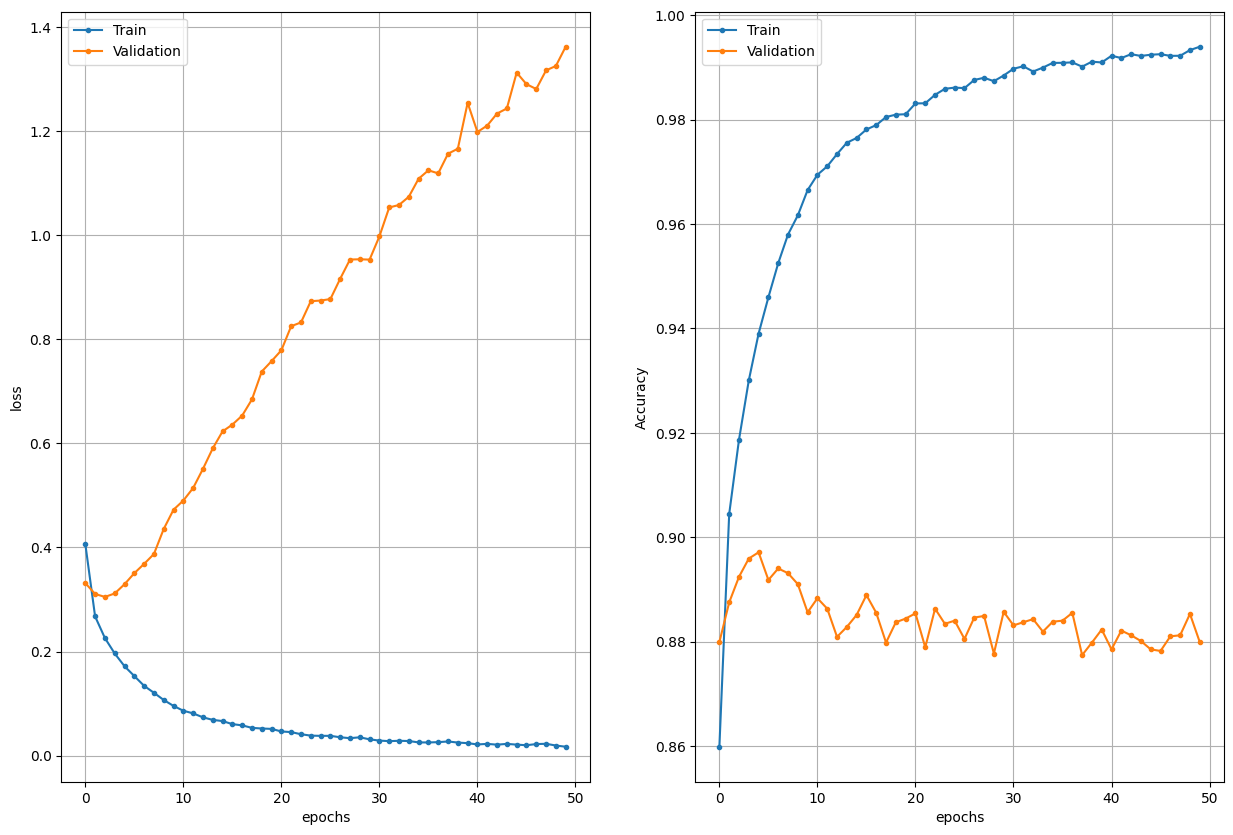

In [10]:
model_baseline_metrics = plot_history(history_baseline)

In [55]:
def plot_confusion_matrix(model, x, y_true, class_names=None):
    if len(y_true.shape) > 1:
        y_true = np.argmax(y_true, axis=1)

    y_pred = np.argmax(model.predict(x), axis=1)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.xlabel('Predicted')
    plt.ylabel('True')

    if class_names is not None:
        plt.xticks(ticks=np.arange(len(class_names)) + 0.5, labels=class_names, rotation=30)
        plt.yticks(ticks=np.arange(len(class_names)) + 0.5, labels=class_names, rotation=0)

    plt.title('Confusion Matrix')
    plt.show()

    return

  1/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


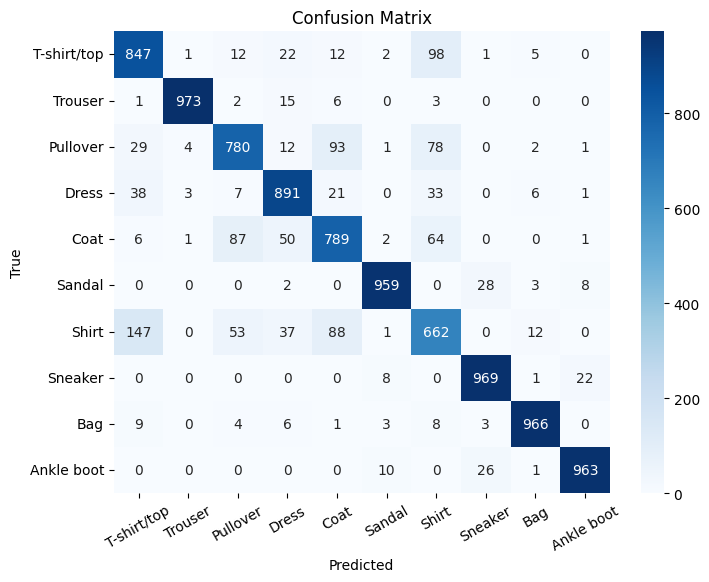

In [ ]:
plot_confusion_matrix(model_baseline, x_test, y_test, class_names=class_names)

As can be observed, the model exhibits clear overfitting: the training accuracy approaches 99%, while the validation accuracy plateaus around 88–89%. At the same time, the training loss continues to decrease, whereas the validation loss steadily increases, further confirming poor generalization to unseen data.

### Combat the Overfitting

The following plan is proposed to address the overfitting observed in the baseline model. Starting from the initial architecture, regularization techniques will be introduced incrementally in order to improve generalization while keeping the model size constrained.

- Model 2: + Pooling
Introduce a pooling layer (e.g., MaxPooling) after the convolutional layer to reduce spatial dimensions and the number of parameters, helping to limit overfitting.

- Model 3: + Dropout
Add dropout layers to randomly deactivate neurons during training, reducing reliance on specific activations and improving robustness.

- Model 4: + L2 Regularization
Apply L2 weight regularization to penalize large weights and encourage simpler models.

- Model 5: Data Augmentation
Increase effective dataset diversity by applying transformations such as rotations, shifts, and flips, improving generalization without increasing model size.

- Model 6: + Batch Normalization
Introduce batch normalization to stabilize training, accelerate convergence, and provide a mild regularization effect.

- Model 7: Early Stopping
Monitor validation performance and stop training when it stops improving, preventing further overfitting.

- Model 8: Hyperparameter Tuning (Optuna)
Apply hyperparameter optimization using Optuna to automatically search for the best configuration of key parameters such as learning rate, dropout rate, and the number of dense units, further improving model performance and generalization.

The goal is to progressively improve validation accuracy above 91% while ensuring that the final model remains no larger than the baseline.

# Model 2: Pooling

To reduce overfitting, a MaxPooling layer is added after the convolutional layer. This reduces the spatial dimensions of feature maps and decreases the number of parameters in the fully connected layer, improving generalization without increasing model complexity.

In [11]:
inputs = Input(shape=(28, 28, 1))

net = Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same")(inputs)
net = MaxPooling2D(pool_size=(2, 2))(net)

net = Flatten()(net)
net = Dense(128, activation="relu")(net)
outputs = Dense(10, activation="softmax")(net)

model_pool = Model(inputs, outputs, name="model_pool")
model_pool.summary()

Model: "model_pool"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 804,554 (3.07 MB)

 Trainable params: 804,554 (3.07 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
epochs = 50
batch_size = 64

model_pool.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history_pool = model_pool.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test))

Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8584 - loss: 0.3991 - val_accuracy: 0.8837 - val_loss: 0.3214
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9025 - loss: 0.2679 - val_accuracy: 0.8946 - val_loss: 0.2836
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9169 - loss: 0.2250 - val_accuracy: 0.9035 - val_loss: 0.2655
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9286 - loss: 0.1938 - val_accuracy: 0.9120 - val_loss: 0.2487
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9394 - loss: 0.1669 - val_accuracy: 0.9134 - val_loss: 0.2475
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9482 - loss: 0.1433 - val_accuracy: 0.9133 - val_loss: 0.2542
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9557 - loss: 0.1230 - val_accuracy: 0.9133 - val_loss: 0.2669
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9627 - loss: 0.1047 - val_accuracy: 0.

Train Acc      0.9974833130836487
Validation Acc 0.917900025844574


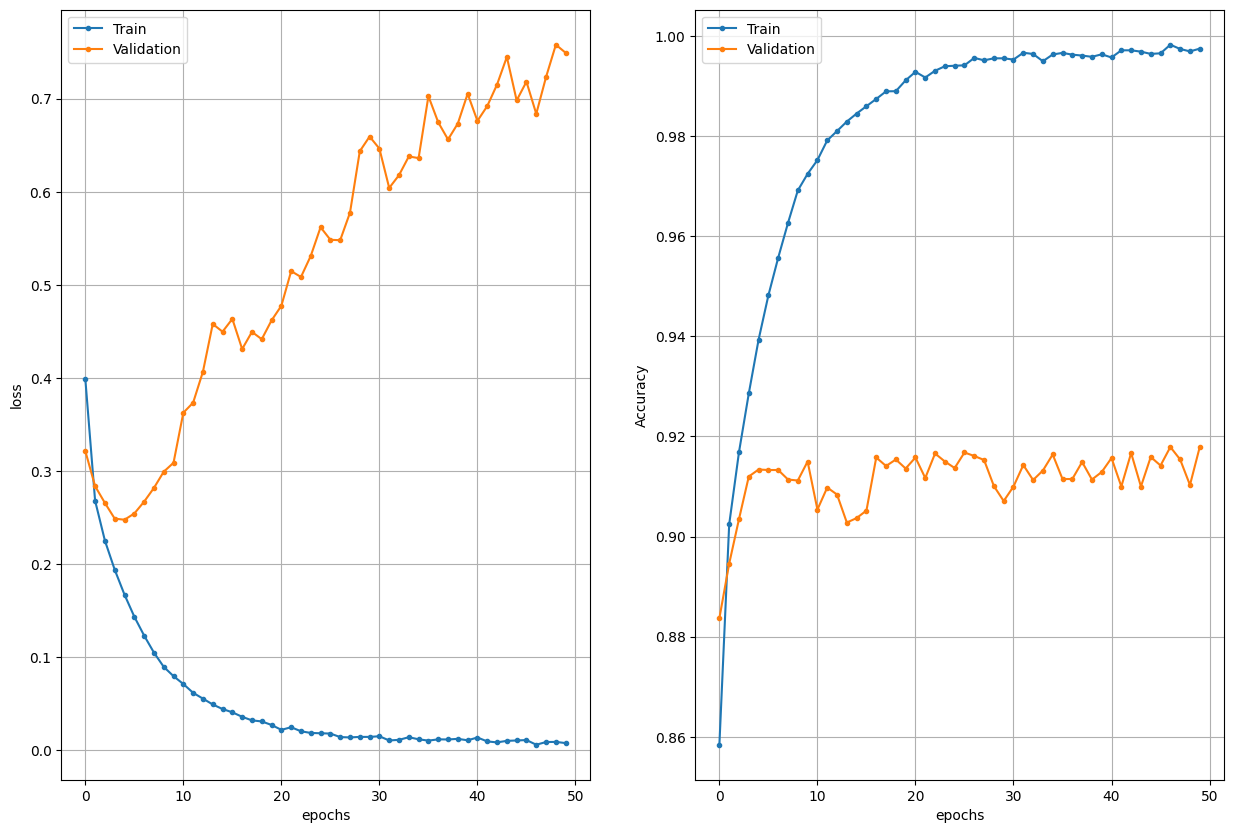

In [13]:
model_pool_metrics = plot_history(history_pool)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


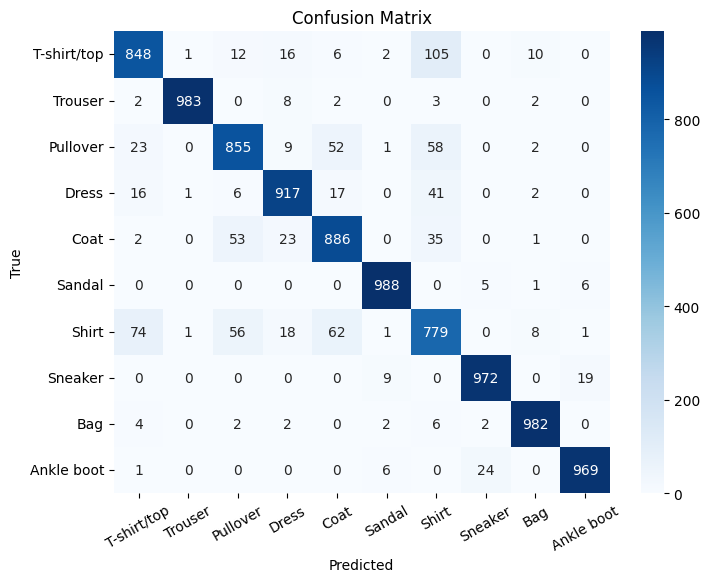

In [ ]:
plot_confusion_matrix(model_pool, x_test, y_test, class_names=class_names)

The introduction of MaxPooling slightly improves validation performance, but the model still exhibits overfitting. The training accuracy quickly approaches 99.7%, while the validation accuracy stabilizes around 91%. Although this meets the target requirement, a clear gap between training and validation metrics remains. The increasing validation loss further indicates limited generalization. Overall, MaxPooling reduces model complexity but is not sufficient to fully address overfitting.

# Model 3: Dropout

To further reduce overfitting, Dropout is introduced after the fully connected layer. This regularization technique randomly deactivates neurons during training, preventing the model from relying too heavily on specific features and improving generalization

In [14]:
from tensorflow.keras.layers import Dropout

inputs = Input(shape=(28, 28, 1))

net = Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
net = MaxPooling2D((2, 2))(net)

net = Flatten()(net)
net = Dense(128, activation="relu")(net)
net = Dropout(0.5)(net)   # ВАЖНО

outputs = Dense(10, activation="softmax")(net)

model_dropout = Model(inputs, outputs, name="model_dropout")
model_dropout.summary()

Model: "model_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 804,554 (3.07 MB)

 Trainable params: 804,554 (3.07 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
epochs = 50
batch_size = 64

model_dropout.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history_dropout = model_dropout.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test))

Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8202 - loss: 0.5153 - val_accuracy: 0.8750 - val_loss: 0.3415
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8774 - loss: 0.3435 - val_accuracy: 0.8898 - val_loss: 0.3025
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8919 - loss: 0.3022 - val_accuracy: 0.8973 - val_loss: 0.2793
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9014 - loss: 0.2780 - val_accuracy: 0.9020 - val_loss: 0.2680
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9046 - loss: 0.2590 - val_accuracy: 0.9034 - val_loss: 0.2651
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9116 - loss: 0.2421 - val_accuracy: 0.9078 - val_loss: 0.2607
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9161 - loss: 0.2276 - val_accuracy: 0.9087 - val_loss: 0.2538
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9213 - loss: 0.2128 - val_accuracy: 

Train Acc      0.9726166725158691
Validation Acc 0.9186000227928162


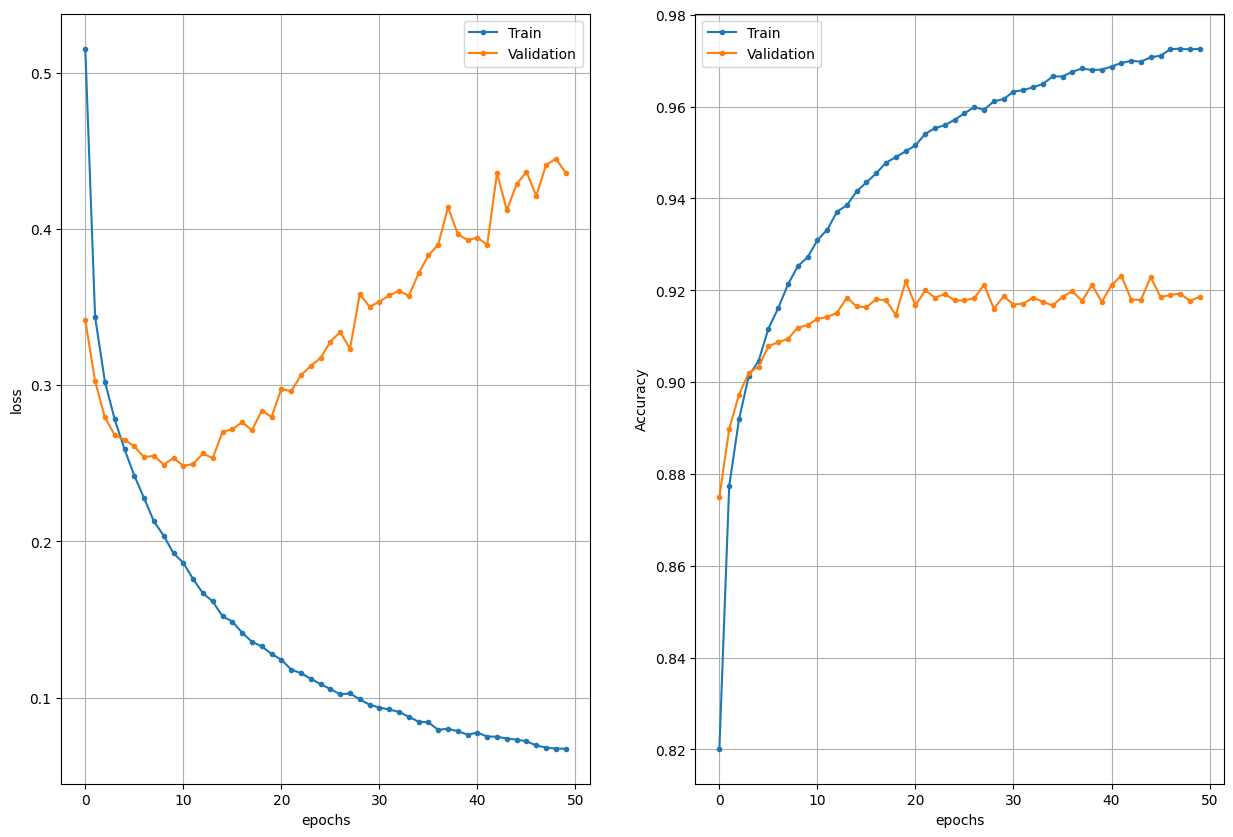

In [16]:
model_dropout_metrics = plot_history(history_dropout)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


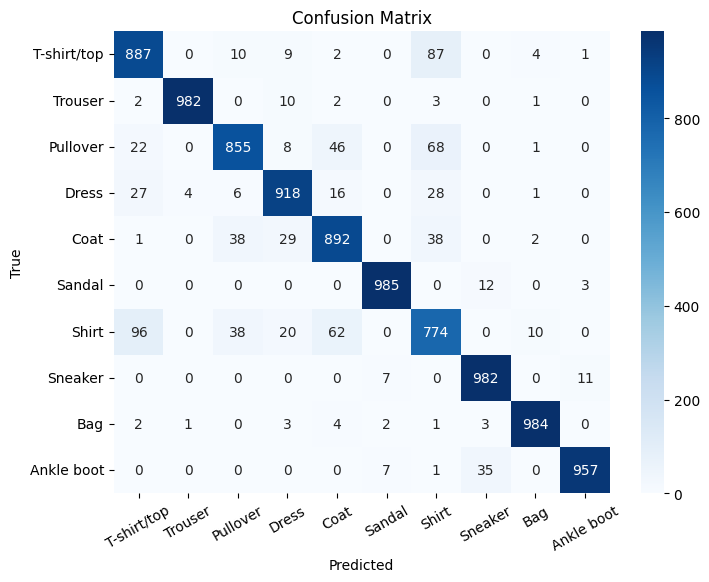

In [59]:
plot_confusion_matrix(model_dropout, x_test, y_test, class_names=class_names)

Adding Dropout significantly reduced overfitting and improved generalization. The training accuracy decreased compared to the previous model, while the validation accuracy increased to approximately 91.86%. The gap between training and validation metrics became smaller, and the training process became more stable. Although slight overfitting is still present, the model demonstrates much better generalization compared to previous architectures.

# Model 4: L2 Regularization

In this model, L2 weight regularization is introduced to penalize large weights and reduce overfitting. This helps the model generalize better by preventing it from becoming too complex.

In [17]:
from tensorflow.keras.regularizers import l2

inputs = Input(shape=(28, 28, 1))

net = Conv2D(32, (3, 3), activation="relu", padding="same",
             kernel_regularizer=l2(1e-4))(inputs)
net = MaxPooling2D((2, 2))(net)

net = Flatten()(net)

net = Dense(128, activation="relu",
            kernel_regularizer=l2(1e-4))(net)

net = Dropout(0.3)(net)

outputs = Dense(10, activation="softmax")(net)

model_l2 = Model(inputs, outputs, name="model_l2")
model_l2.summary()

Model: "model_l2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 804,554 (3.07 MB)

 Trainable params: 804,554 (3.07 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model_l2.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

history_l2 = model_l2.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=50,
    validation_data=(x_test, y_test)
)

Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8414 - loss: 0.4888 - val_accuracy: 0.8847 - val_loss: 0.3740
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8871 - loss: 0.3695 - val_accuracy: 0.8895 - val_loss: 0.3562
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8972 - loss: 0.3426 - val_accuracy: 0.8943 - val_loss: 0.3433
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9026 - loss: 0.3274 - val_accuracy: 0.9015 - val_loss: 0.3321
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9083 - loss: 0.3181 - val_accuracy: 0.9020 - val_loss: 0.3330
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9114 - loss: 0.3073 - val_accuracy: 0.9027 - val_loss: 0.3301
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9156 - loss: 0.3021 - val_accuracy: 0.9025 - val_loss: 0.3327
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9185 - loss: 0.2952 - val_accura

Train Acc      0.958133339881897
Validation Acc 0.9125000238418579


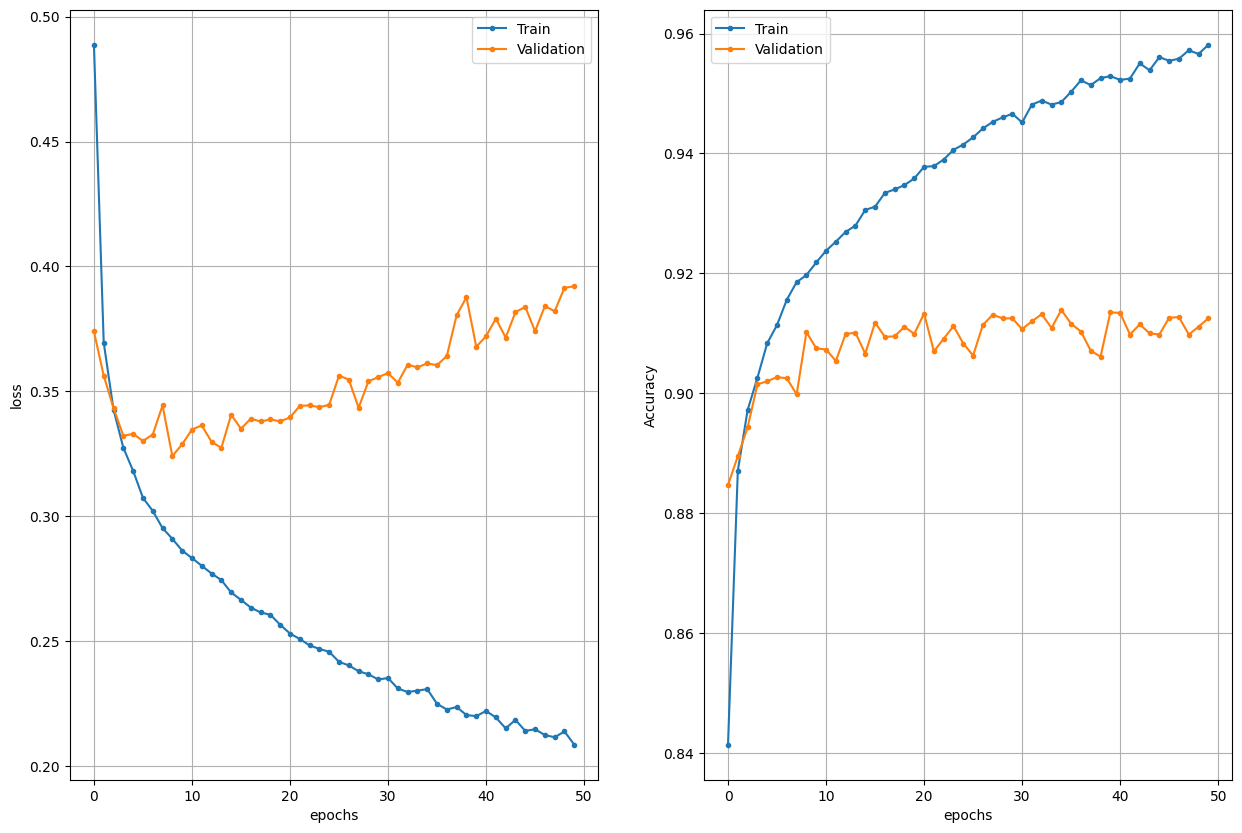

In [19]:
model_l2_metrics = plot_history(history_l2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


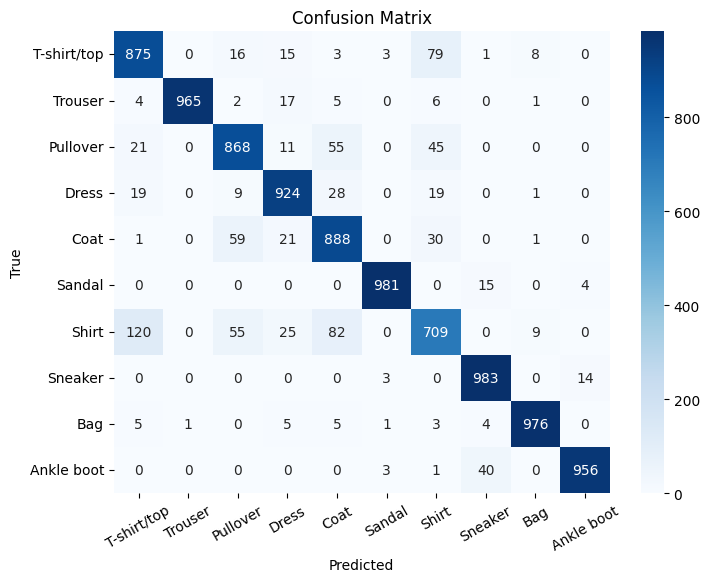

In [60]:
plot_confusion_matrix(model_l2, x_test, y_test, class_names=class_names)

L2 regularization reduces overfitting and leads to more stable training compared to the baseline. The validation accuracy improves to around 91%, although it remains slightly lower than with dropout. The gap between training and validation metrics is reduced, indicating better generalization. However, some overfitting is still present, as the validation loss continues to increase.

# Model 5: Data Augmentation

In this model, data augmentation is applied to artificially increase the diversity of the training data. This helps the model become more robust to variations in input images and can improve generalization.

In [20]:
x_train_aug = x_train[..., np.newaxis]
x_test_aug = x_test[..., np.newaxis]

print(x_train.shape)
print(x_train_aug.shape)

(60000, 28, 28)
(60000, 28, 28, 1)


In [21]:
inputs = Input(shape=(28, 28, 1))

net = Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
net = MaxPooling2D((2, 2))(net)

net = Flatten()(net)
net = Dense(128, activation="relu")(net)
net = Dropout(0.3)(net)

outputs = Dense(10, activation="softmax")(net)

model_aug = Model(inputs, outputs, name="model_aug")
model_aug.summary()

Model: "model_aug"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 804,554 (3.07 MB)

 Trainable params: 804,554 (3.07 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
epochs = 50
batch_size = 64

model_aug.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.08
)

history_aug = model_aug.fit(
    datagen.flow(x_train_aug, y_train, batch_size=batch_size),
    epochs=epochs,
    validation_data=(x_test_aug, y_test)
)

Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.7516 - loss: 0.6692 - val_accuracy: 0.8236 - val_loss: 0.4541
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.8141 - loss: 0.5002 - val_accuracy: 0.8522 - val_loss: 0.3924
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.8326 - loss: 0.4508 - val_accuracy: 0.8757 - val_loss: 0.3483
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.8421 - loss: 0.4268 - val_accuracy: 0.8805 - val_loss: 0.3289
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.8481 - loss: 0.4106 - val_accuracy: 0.8866 - val_loss: 0.3110
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.8533 - loss: 0.3920 - val_accuracy: 0.8856 - val_loss: 0.3098
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.8566 - loss: 0.3832 - val_accuracy: 0.8869 - val_loss: 0.3147
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.8617 - loss: 0.3725 - 

Train Acc      0.8940833210945129
Validation Acc 0.9081000089645386


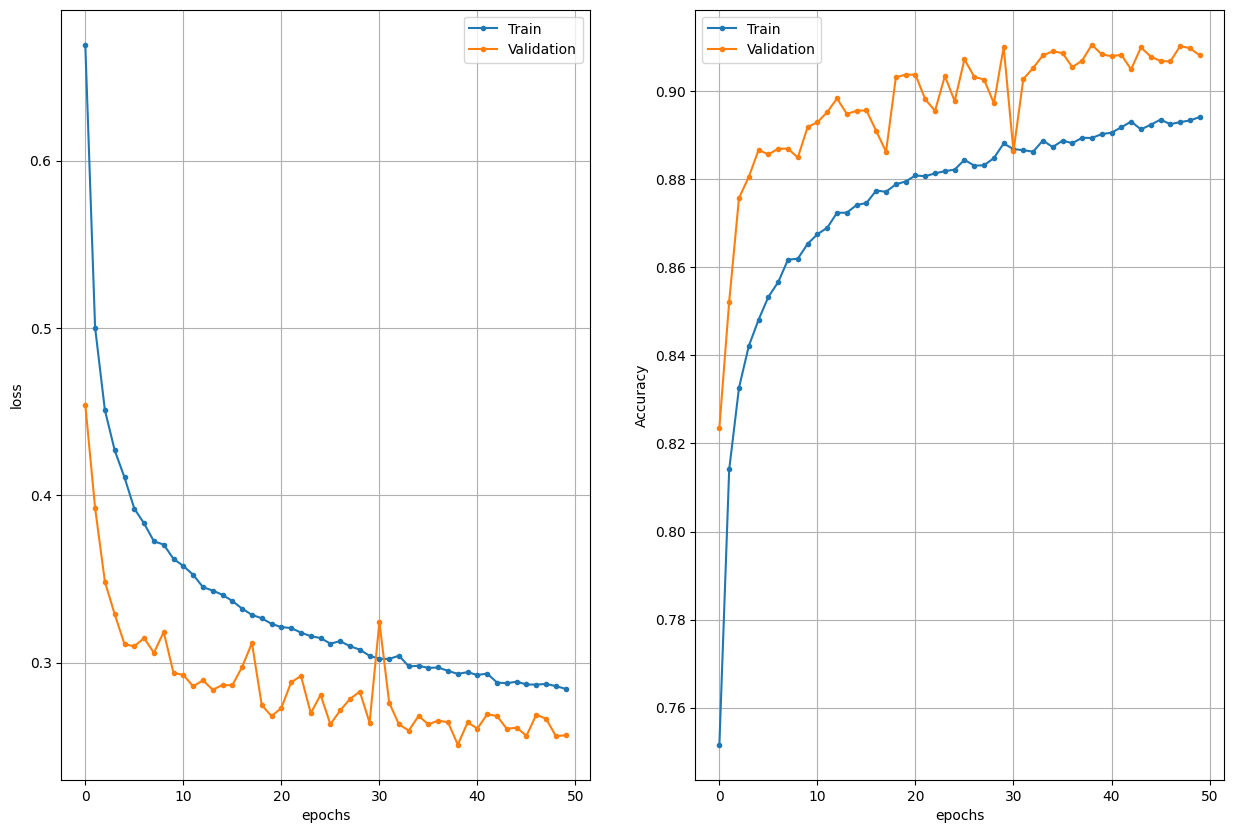

In [24]:
model_aug_metrics = plot_history(history_aug)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


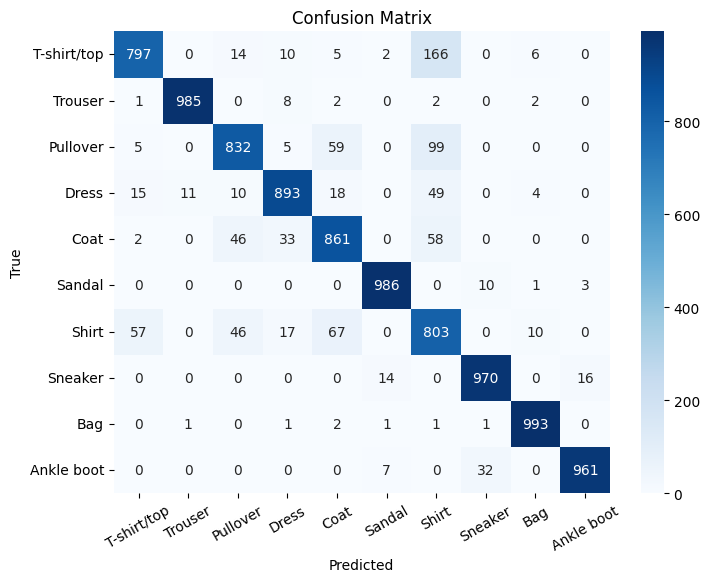

In [61]:
plot_confusion_matrix(model_aug, x_test, y_test, class_names=class_names)

Data augmentation does not significantly improve validation accuracy, which remains around 90–91%. However, it helps reduce overfitting, as indicated by the smaller gap between training and validation metrics and the more stable validation loss. This suggests improved generalization, even though the overall classification performance does not increase. The limited impact may be due to the simplicity of the Fashion MNIST dataset and the presence of other regularization techniques such as dropout.

# Model 6: Batch Normalization

Batch normalization is introduced to stabilize and accelerate training by normalizing layer activations, which can also provide a regularization effect and improve generalization.

In [25]:
from tensorflow.keras.layers import BatchNormalization

inputs = Input(shape=(28, 28, 1))

net = Conv2D(32, (3, 3), padding="same")(inputs)
net = BatchNormalization()(net)
net = tf.keras.layers.Activation("relu")(net)

net = MaxPooling2D((2, 2))(net)

net = Flatten()(net)
net = Dense(128, activation="relu")(net)
net = Dropout(0.3)(net)

outputs = Dense(10, activation="softmax")(net)

model_bn = Model(inputs, outputs, name="model_bn")

In [26]:
batch_size=64
epochs=50

model_bn.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

history_bn = model_bn.fit(
    x_train_aug, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(x_test_aug, y_test)
)

Epoch 1/50


938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.8282 - loss: 0.4845 - val_accuracy: 0.8732 - val_loss: 0.3361
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8780 - loss: 0.3371 - val_accuracy: 0.8928 - val_loss: 0.2948
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8900 - loss: 0.3021 - val_accuracy: 0.8944 - val_loss: 0.2899
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9001 - loss: 0.2751 - val_accuracy: 0.8971 - val_loss: 0.2844
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9076 - loss: 0.2539 - val_accuracy: 0.8989 - val_loss: 0.2894
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9124 - loss: 0.2371 - val_accuracy: 0.9031 - val_loss: 0.2810
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9183 - loss: 0.2186 - val_accuracy: 0.9037 - val_loss: 0.2799
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9201 - loss: 0.2109 - val_accurac

Train Acc      0.9718166589736938
Validation Acc 0.9135000109672546


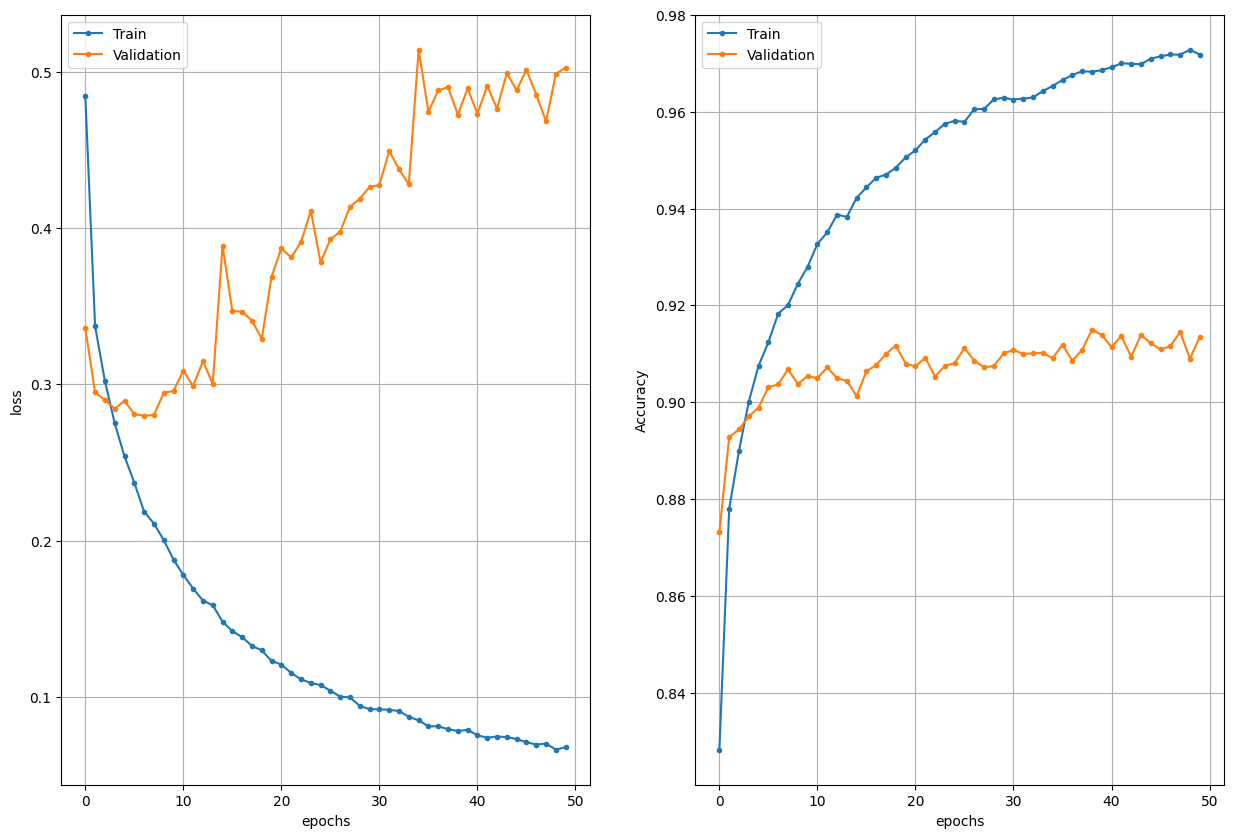

In [27]:
model_bn_metrics = plot_history(history_bn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


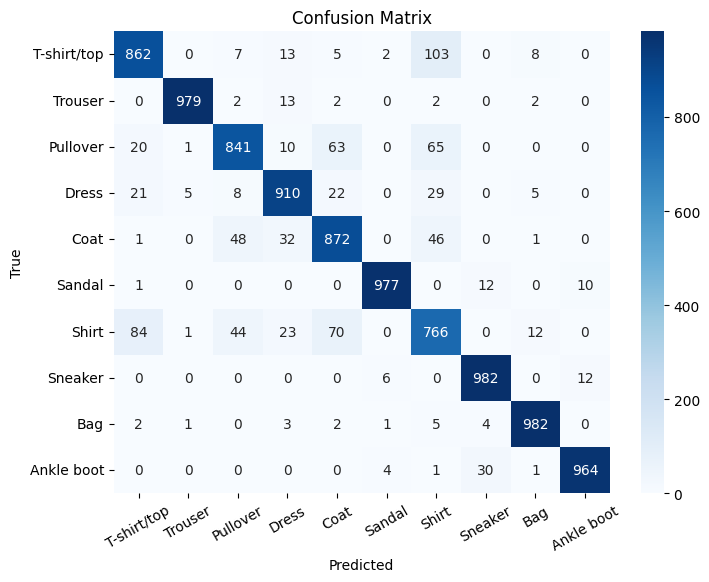

In [62]:
plot_confusion_matrix(model_bn, x_test, y_test, class_names=class_names)

Adding Batch Normalization does not improve overall model performance. The validation accuracy remains around 91% and does not surpass the Dropout model. Although training becomes more stable, the validation loss increases during training, indicating persistent overfitting. This suggests that Batch Normalization does not provide significant benefits for this relatively simple architecture.

# Model 7: Early Stopping

To further improve generalization and prevent unnecessary overfitting, Early Stopping is introduced. This technique stops training when the validation performance stops improving, ensuring that the model does not continue learning noise from the training data.

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_dropout.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

history_early = model_dropout.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=50,
    validation_data=(x_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9732 - loss: 0.0663 - val_accuracy: 0.9216 - val_loss: 0.4528
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9736 - loss: 0.0654 - val_accuracy: 0.9186 - val_loss: 0.4647
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9742 - loss: 0.0632 - val_accuracy: 0.9232 - val_loss: 0.4857
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9743 - loss: 0.0634 - val_accuracy: 0.9204 - val_loss: 0.4584
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9746 - loss: 0.0630 - val_accuracy: 0.9193 - val_loss: 0.4869
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9760 - loss: 0.0595 - val_accuracy: 0.9220 - val_loss: 0.4724


Train Acc      0.976016640663147
Validation Acc 0.921999990940094


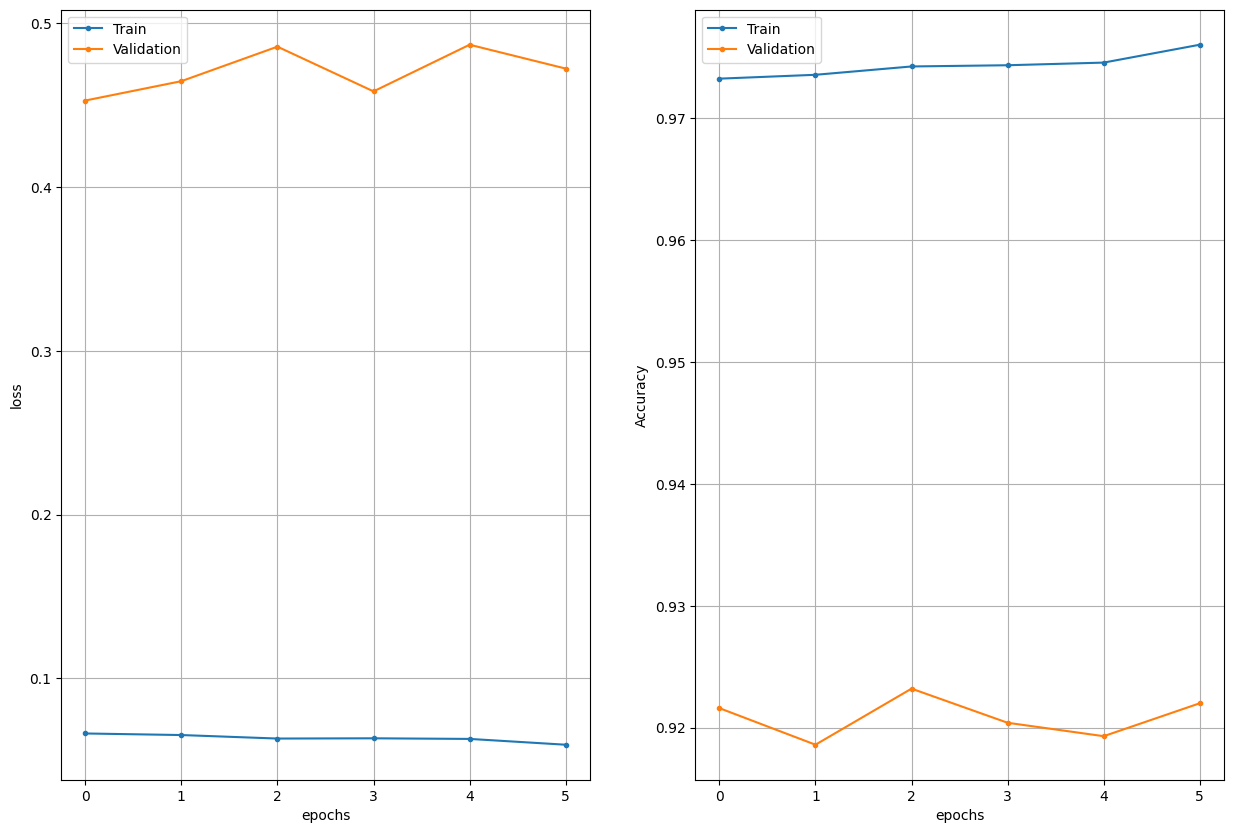

In [85]:
model_early_metrics = plot_history(history_early)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


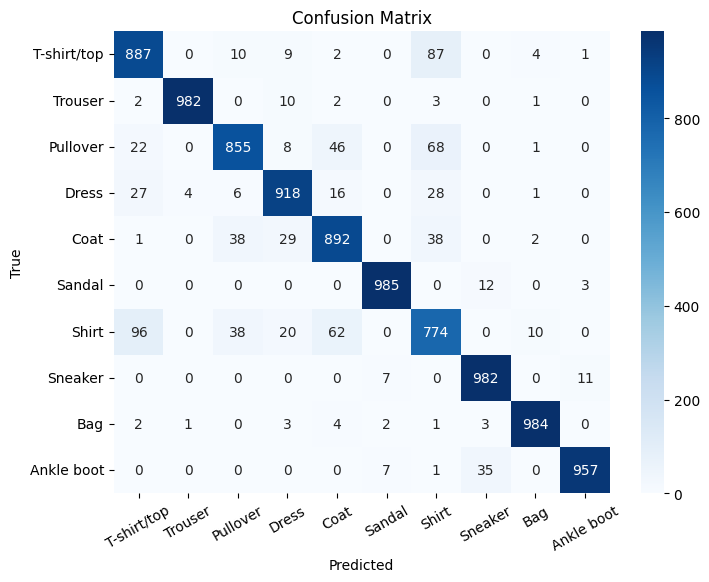

In [63]:
plot_confusion_matrix(model_dropout, x_test, y_test, class_names=class_names)

Applying Early Stopping to the Dropout model effectively reduces overfitting by terminating training at an optimal point. The model achieves stable validation accuracy around 92% while preventing the increase in validation loss observed in previous experiments. The gap between training and validation metrics remains small, indicating improved generalization. Overall, Early Stopping helps retain the best model performance without unnecessary training.

# Model 8: Hyperparameter Tuning with Optuna

To further improve the performance of the best-performing model, hyperparameter tuning is applied using Optuna. This approach searches for optimal values of key parameters such as learning rate, dropout rate, and the number of dense units, aiming to enhance generalization and overall accuracy.

In [75]:
def objective(trial):
    dropout_rate = trial.suggest_float("dropout", 0.2, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    dense_units = trial.suggest_categorical("dense_units", [64, 128, 256])

    inputs = Input(shape=(28, 28, 1))
    x = Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = MaxPooling2D((2, 2))(x)
    x = Flatten()(x)
    x = Dense(dense_units, activation="relu")(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(10, activation="softmax")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        x_train, y_train,
        validation_data=(x_test, y_test),
        epochs=10,
        batch_size=64,
        verbose=0
    )

    return max(history.history["val_accuracy"])


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("Best params:", study.best_params)

[I 2026-03-30 19:38:51,299] A new study created in memory with name: no-name-e08a01d8-1561-453b-8a81-fcbd9107e80c
[I 2026-03-30 19:40:18,445] Trial 0 finished with value: 0.8960000276565552 and parameters: {'dropout': 0.44200287789179493, 'lr': 0.008525413602170094, 'dense_units': 128}. Best is trial 0 with value: 0.8960000276565552.
[I 2026-03-30 19:41:58,127] Trial 1 finished with value: 0.916700005531311 and parameters: {'dropout': 0.4927842217765333, 'lr': 0.00035960341899456756, 'dense_units': 256}. Best is trial 1 with value: 0.916700005531311.
[I 2026-03-30 19:43:23,732] Trial 2 finished with value: 0.9042999744415283 and parameters: {'dropout': 0.3458643566812982, 'lr': 0.00021914642720831284, 'dense_units': 128}. Best is trial 1 with value: 0.916700005531311.
[I 2026-03-30 19:44:58,357] Trial 3 finished with value: 0.9064000248908997 and parameters: {'dropout': 0.3086932667544151, 'lr': 0.004654380433307208, 'dense_units': 256}. Best is trial 1 with value: 0.916700005531311.
[

Best params: {'dropout': 0.4927842217765333, 'lr': 0.00035960341899456756, 'dense_units': 256}


In [77]:
best = study.best_params

inputs = Input(shape=(28, 28, 1))

x = Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
x = MaxPooling2D((2, 2))(x)

x = Flatten()(x)
x = Dense(best["dense_units"], activation="relu")(x)
x = Dropout(best["dropout"])(x)

outputs = Dense(10, activation="softmax")(x)

model_final = Model(inputs, outputs)

In [78]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [79]:
model_final.compile(
    optimizer=Adam(learning_rate=best["lr"]),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_final = model_final.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8094 - loss: 0.5438 - val_accuracy: 0.8660 - val_loss: 0.3760
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8709 - loss: 0.3615 - val_accuracy: 0.8814 - val_loss: 0.3283
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8896 - loss: 0.3132 - val_accuracy: 0.8909 - val_loss: 0.3013
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8987 - loss: 0.2834 - val_accuracy: 0.8961 - val_loss: 0.2800
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9073 - loss: 0.2605 - val_accuracy: 0.8982 - val_loss: 0.2712
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9117 - loss: 0.2418 - val_accuracy: 0.9034 - val_loss: 0.2641
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9179 - loss: 0.2259 - val_accuracy: 0.9065 - val_loss: 0.2550
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9222 - loss: 0.2151 - 

Train Acc      0.9524333477020264
Validation Acc 0.9225999712944031


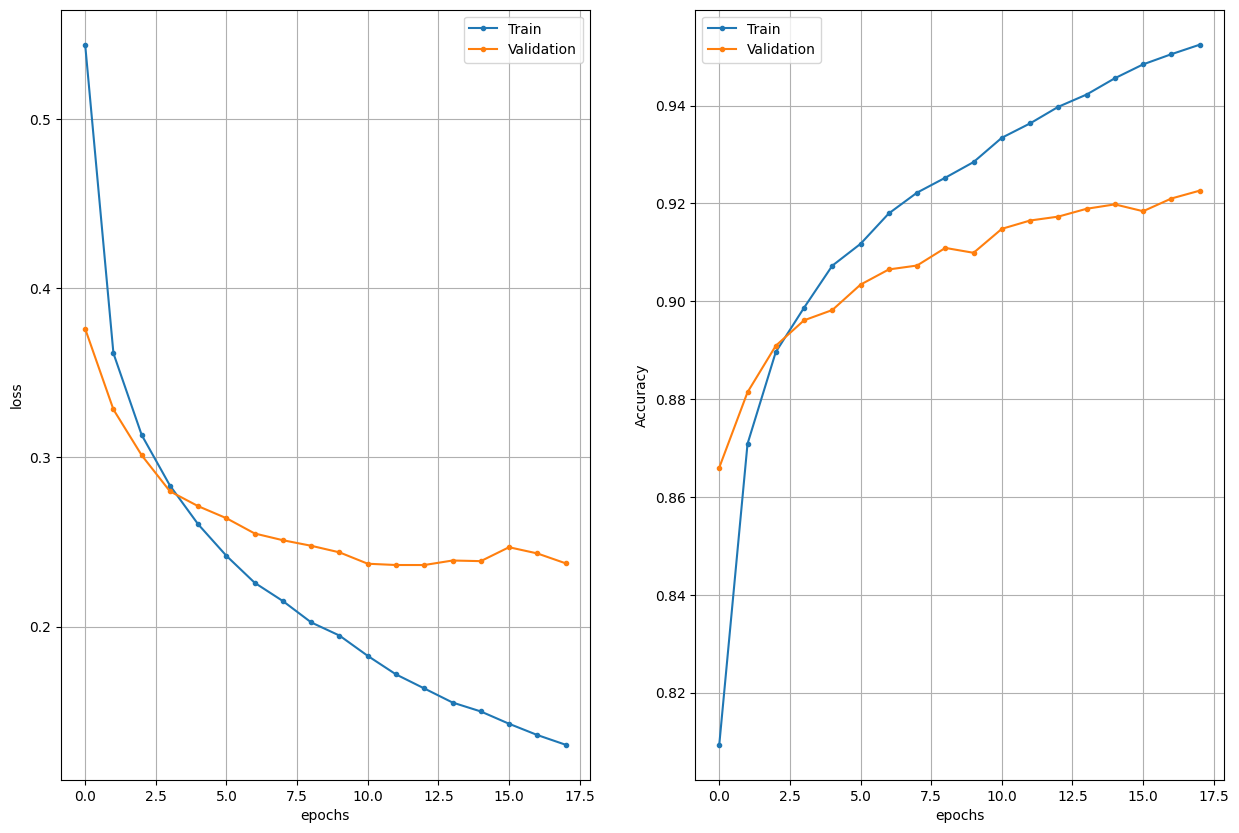

In [84]:
model_final_metrics = plot_history(history_final)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


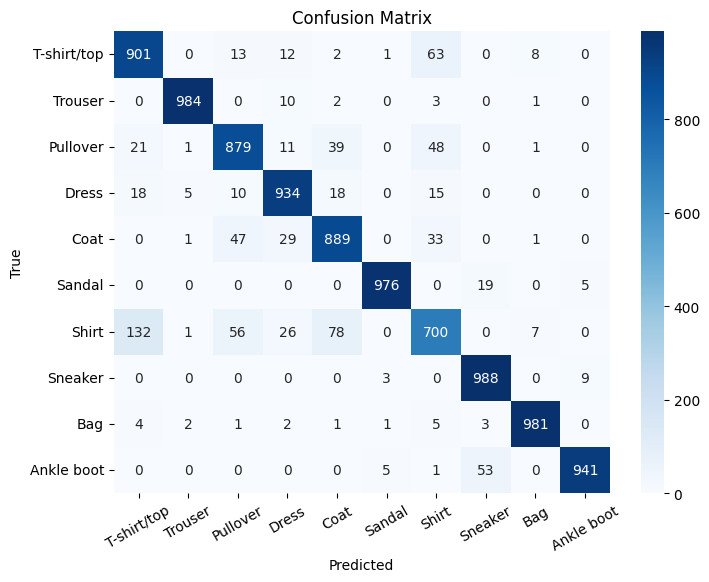

In [80]:
plot_confusion_matrix(model_final, x_test, y_test, class_names=class_names)

Hyperparameter tuning with Optuna led to a slight improvement in validation performance, achieving approximately 92.3% accuracy. The model maintains a relatively small gap between training and validation accuracy, indicating good generalization. The confusion matrix shows that most classes are classified correctly, although some confusion remains between visually similar categories such as shirts, pullovers, and coats. Overall, tuning further refined the model but did not drastically change performance compared to the Dropout + Early Stopping baseline.

# Model Comparison

In [76]:
def build_results_table(models_metrics):
    rows = []

    for name, metrics in models_metrics.items():
        train_acc, val_acc = metrics
        rows.append([name, train_acc, val_acc])

    df = pd.DataFrame(rows, columns=["Model", "Train Accuracy", "Validation Accuracy"])
    return df.sort_values(by="Validation Accuracy", ascending=False)

In [86]:
models_metrics = {
    "Baseline": model_baseline_metrics,
    "Pooling": model_pool_metrics,
    "Dropout": model_dropout_metrics,
    "L2": model_l2_metrics,
    "Augmentation": model_aug_metrics,
    "BatchNorm": model_bn_metrics,
    "EarlyStopping": model_early_metrics,
    "Optuna + EarlyStopping": model_final_metrics
}

results = build_results_table(models_metrics)
results

,Model,Train Accuracy,Validation Accuracy
7,Optuna + EarlyStopping,0.952433,0.9226
6,EarlyStopping,0.976017,0.9220
2,Dropout,0.972617,0.9186
1,Pooling,0.997483,0.9179
5,BatchNorm,0.971817,0.9135
3,L2,0.958133,0.9125
4,Augmentation,0.894083,0.9081
0,Baseline,0.993967,0.8799


## Final comparison summary

The comparison of all models shows a clear progression in performance as regularization techniques are introduced. The baseline model suffers from severe overfitting, achieving high training accuracy (≈99%) but low validation accuracy (≈88%).

The addition of pooling and dropout significantly improves generalization, with dropout providing one of the best trade-offs between bias and variance. Further techniques such as L2 regularization, batch normalization, and data augmentation contribute to stabilizing training but do not outperform dropout.

Early Stopping proves to be one of the most effective methods, achieving high validation accuracy (~92.2%) while reducing overfitting. Finally, hyperparameter tuning with Optuna provides a slight additional improvement, reaching the best validation accuracy (~92.3%) with a smaller train-validation gap.

Overall, the best performance is achieved by combining Dropout, Early Stopping, and hyperparameter tuning, demonstrating that careful regularization and optimization are key to improving model generalization. The relatively small performance gains from more advanced techniques suggest that the Fashion MNIST dataset is relatively simple, and that most improvements come from controlling overfitting rather than increasing model complexity.